# Những thư viện sử dụng cho việc Tiền xử lí dữ liệu dạng Bảng:

- Chạy đoạn code bên dưới nếu chưa tải những thư viện cần thiết

In [25]:
%pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Khai báo những thư viện cần thiết

In [26]:
import shutil
import os
import kagglehub
import pandas as pd
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## I. Tải xuống bộ dữ liệu:

Trong bước này, chúng em tải bộ dữ liệu đã chọn trực tiếp từ **Kaggle** bằng thư viện `kagglehub`. Sau khi tải xuống, toàn bộ các tệp dữ liệu sẽ được sao chép vào cấu trúc thư mục dự án đã được định nghĩa trước (`data/tabular/`). 

In [27]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Đường dẫn đến tập dữ liệu:", path)

destination = "../data/tabular"
os.makedirs(destination, exist_ok=True)

moved = 0

for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            src = os.path.join(root, file)
            dst = os.path.join(destination, file)

            shutil.copy2(src, dst)
            moved += 1
            print(f"Đã sao chép: {file}")

print(f"Đã di chuyển {moved} tệp đến {destination}")

Đường dẫn đến tập dữ liệu: C:\Users\AnhTris\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
Đã sao chép: creditcard.csv
Đã di chuyển 1 tệp đến ../data/tabular
Đường dẫn đến tập dữ liệu: C:\Users\AnhTris\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
Đã sao chép: creditcard.csv
Đã di chuyển 1 tệp đến ../data/tabular


## Mô tả tập dữ liệu

Sau khi tải xuống và tổ chức tập dữ liệu, tệp sau đã có sẵn trong thư mục `data/tabular/`:

```text
data/tabular/
└── creditcard.csv
```

Tệp này chứa **bộ dữ liệu Phát hiện Gian lận Thẻ Tín dụng (Credit Card Fraud Detection)**, được sử dụng cho các bước **phân tích dữ liệu khám phá (EDA)**, **tiền xử lý dữ liệu**, và **xây dựng các mô hình phân loại** nhằm phát hiện các giao dịch gian lận.

### Đặc điểm chính của tập dữ liệu

* Đại diện cho **các giao dịch thẻ tín dụng trong thực tế** do các chủ thẻ châu Âu thực hiện trong **hai ngày liên tiếp** vào tháng 9 năm 2013.
* Là một tập dữ liệu **mất cân bằng nghiêm trọng**, chỉ có **492 giao dịch gian lận** trên tổng số **284.807 giao dịch** (tương đương khoảng **0,172%**).
* Được thiết kế chuyên biệt cho các bài toán **phát hiện gian lận** và **phát hiện bất thường**, nơi mà các thước đo độ chính xác thông thường (accuracy) là **không đủ để đánh giá mô hình**.

### Các loại đặc trưng trong tập dữ liệu

* **Các đặc trưng giao dịch đã được ẩn danh** (`V1`–`V28`):

  * Là các đặc trưng số được tạo ra thông qua **Phân tích Thành phần Chính (PCA)** nhằm bảo vệ thông tin nhạy cảm của khách hàng.
  * Giúp nắm bắt các mẫu (patterns) tiềm ẩn của giao dịch mà không làm lộ các thuộc tính gốc.

* **Các đặc trưng không qua PCA**:

  * `Time`: Số giây trôi qua kể từ giao dịch đầu tiên trong tập dữ liệu.
  * `Amount`: Giá trị của giao dịch.

* **Biến mục tiêu (Target variable)**:

  * `Class`: Nhãn nhị phân biểu thị loại giao dịch

    * `1` → Giao dịch gian lận
    * `0` → Giao dịch hợp lệ

### Nguồn dữ liệu

**Kaggle** – *Credit Card Fraud Detection*
[https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


## II. Lưu dataset vào biến

In [28]:
destination = "../data/tabular"
data = pd.read_csv(os.path.join(destination, "creditcard.csv"))

### Một số thông tin cơ bản của tập dữ liệu

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### III. Xử lí những phần dữ liệu bị thiếu: 

- Tìm tất cả các cột có dữ liệu bị thiếu

In [30]:
# In thông tin về các cột có giá trị thiếu

missing_columns = data.columns[data.isnull().any()]
missing_info = []
for col in missing_columns:
    missing_count = data[col].isnull().sum()
    missing_pct = (missing_count / len(data)) * 100
    dtype = data[col].dtype
    
    missing_info.append({
        'Cột': col,
        'Kiểu dữ liệu': dtype,
        'Số lượng thiếu': missing_count,
        'Tỷ lệ thiếu %': f"{missing_pct:.2f}%"
    })

missing_df = pd.DataFrame(missing_info)
print(f"\nTổng số cột có giá trị thiếu: {len(missing_columns)}")
print(f"Tổng số cột trong tập dữ liệu: {len(data.columns)}\n")
print(missing_df.to_string(index=False))

print("\n" + "="*60)


Tổng số cột có giá trị thiếu: 0
Tổng số cột trong tập dữ liệu: 31

Empty DataFrame
Columns: []
Index: []



&rarr; Vì tập dữ liệu chúng ta không bị thiếu nên ta sẽ không cần xử lí việc thiếu dữ liệu

### IV. Data Normalization:

- Trong tập dữ liệu này, các đặc trưng `V1 - V28` đã được chuẩn hóa nên ta sẽ không xét đến chúng

In [31]:
# Lấy danh sách các cột số, loại bỏ cột 'Class' và các cột 'V1' đến 'V28'
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Class'] + [f'V{i}' for i in range(1, 29)]]

- Kiểm tra các giá trị ngoại lai trong tập dữ liệu

In [32]:
print(f"\nSố cột số để chuẩn hóa: {len(numerical_cols)}")
print(f"Các cột: {numerical_cols}")

# Kiểm tra giá trị ngoại lai trước khi chuẩn hóa
print("\n" + "-"*60)
print("Kiểm tra giá trị ngoại lai trước khi chuẩn hóa:")
print("-"*60)

outlier_summary = {}
for col in numerical_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(data)) * 100
    
    outlier_summary[col] = outlier_count
    print(f"{col}: {outlier_count} giá trị ngoại lai ({outlier_pct:.2f}%)")


Số cột số để chuẩn hóa: 2
Các cột: ['Time', 'Amount']

------------------------------------------------------------
Kiểm tra giá trị ngoại lai trước khi chuẩn hóa:
------------------------------------------------------------
Time: 0 giá trị ngoại lai (0.00%)
Amount: 31904 giá trị ngoại lai (11.20%)
Time: 0 giá trị ngoại lai (0.00%)
Amount: 31904 giá trị ngoại lai (11.20%)


- Sử dụng các phương pháp khác nhau trong việc chuẩn hóa để xem những kết quả chuẩn hóa

In [33]:
# Chuẩn hóa dữ liệu sử dụng Min-Max Scaling, Standardization và Robust Scaling
data_minmax = data.copy()
data_standard = data.copy()
data_robust = data.copy()

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


data_minmax[numerical_cols] = minmax_scaler.fit_transform(data[numerical_cols])
data_standard[numerical_cols] = standard_scaler.fit_transform(data[numerical_cols])
data_robust[numerical_cols] = robust_scaler.fit_transform(data[numerical_cols])

In [34]:
print("\n" + "="*60)
print("So sánh thống kê giữa các phương pháp chuẩn hóa:")
print("="*60)

for col in numerical_cols:
    print(f"\nCột: {col}")
    stats = pd.DataFrame({
        'Phương pháp': ['Gốc', 'Min-Max', 'Chuẩn hóa', 'Robust'],
        'Trung bình': [
            data[col].mean(),
            data_minmax[col].mean(),
            data_standard[col].mean(),
            data_robust[col].mean()
        ],
        'Độ lệch chuẩn': [
            data[col].std(),
            data_minmax[col].std(),
            data_standard[col].std(),
            data_robust[col].std()
        ],
        'Giá trị nhỏ nhất': [
            data[col].min(),
            data_minmax[col].min(),
            data_standard[col].min(),
            data_robust[col].min()
        ],
        'Giá trị lớn nhất': [
            data[col].max(),
            data_minmax[col].max(),
            data_standard[col].max(),
            data_robust[col].max()
        ]
    })
    print(stats.to_string(index=False))


So sánh thống kê giữa các phương pháp chuẩn hóa:

Cột: Time
Phương pháp    Trung bình  Độ lệch chuẩn  Giá trị nhỏ nhất  Giá trị lớn nhất
        Gốc  9.481386e+04   47488.145955          0.000000     172792.000000
    Min-Max  5.487167e-01       0.274828          0.000000          1.000000
  Chuẩn hóa -3.065637e-16       1.000002         -1.996583          1.642058
     Robust  1.189142e-01       0.557903         -0.994983          1.035022

Cột: Amount
Phương pháp   Trung bình  Độ lệch chuẩn  Giá trị nhỏ nhất  Giá trị lớn nhất
        Gốc 8.834962e+01     250.120109          0.000000      25691.160000
    Min-Max 3.438911e-03       0.009736          0.000000          1.000000
  Chuẩn hóa 2.913952e-17       1.000002         -0.353229        102.362243
     Robust 9.271239e-01       3.495006         -0.307413        358.683155


- Phân phối trước và sau khi được chuẩn hóa.

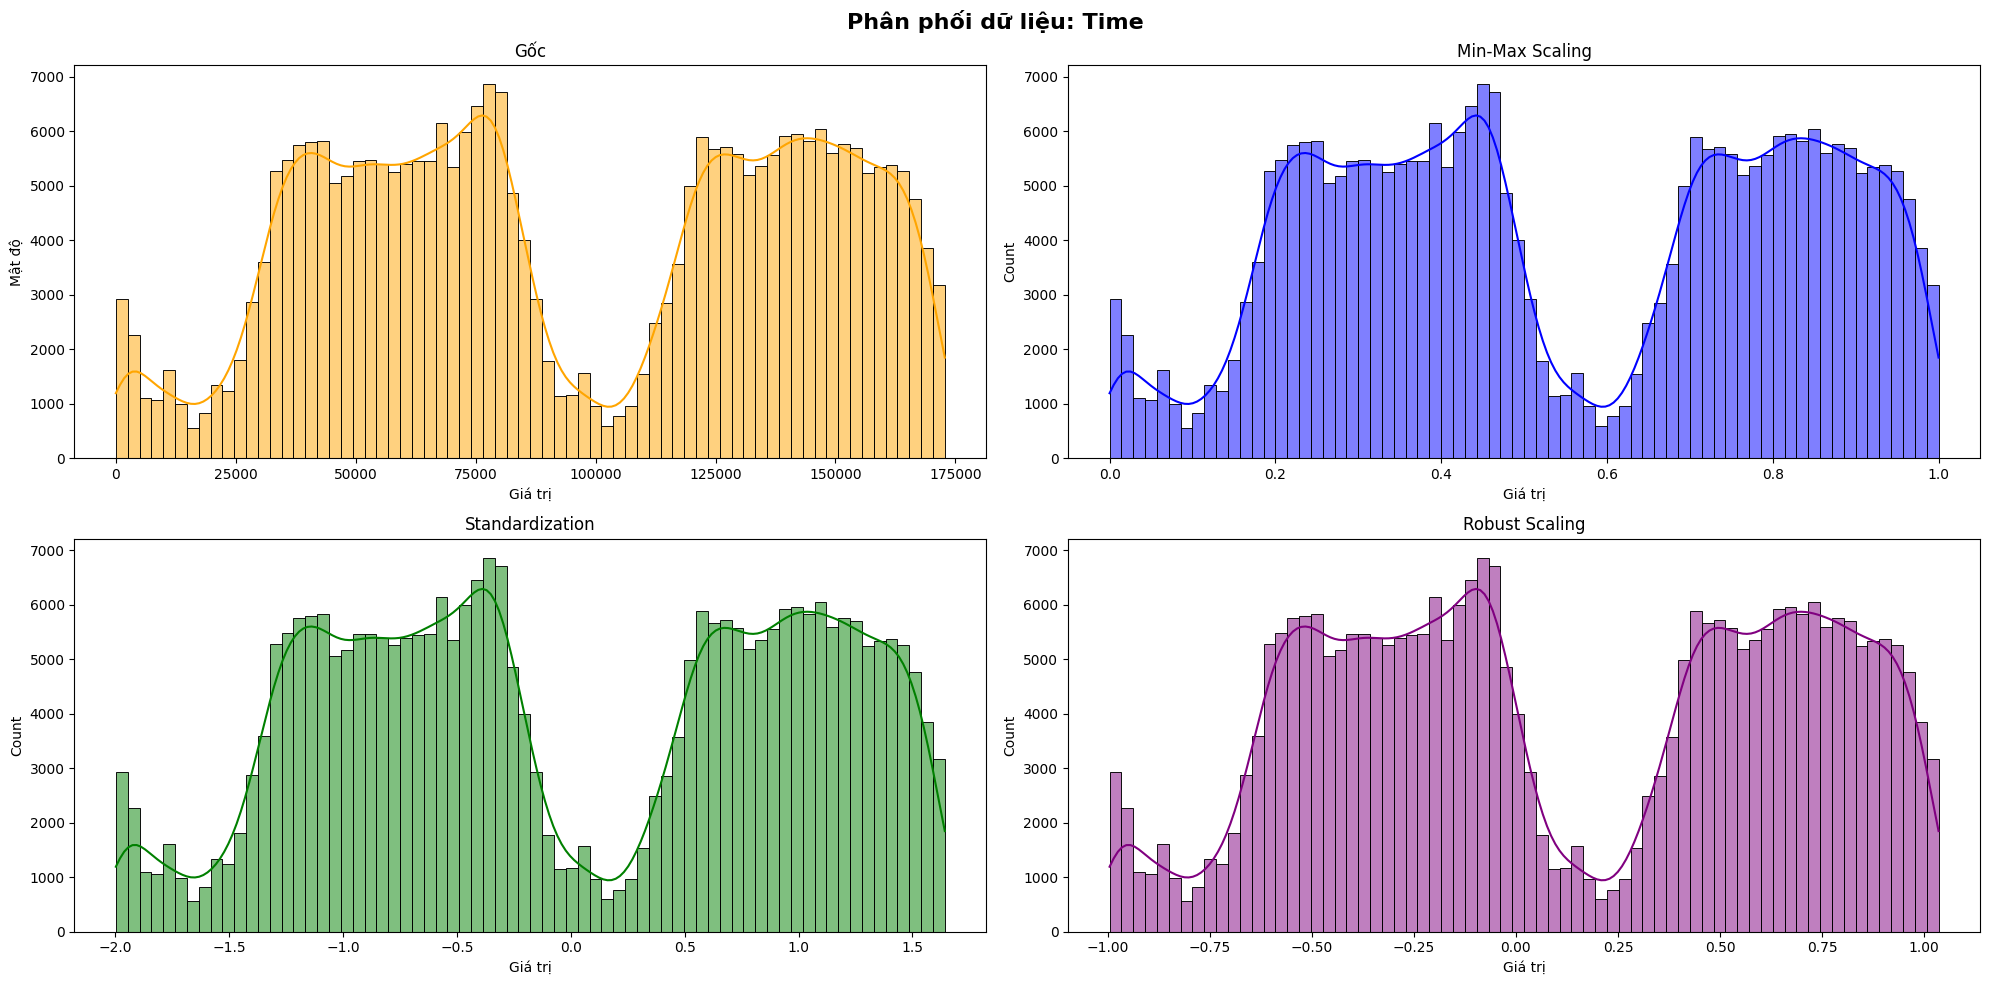

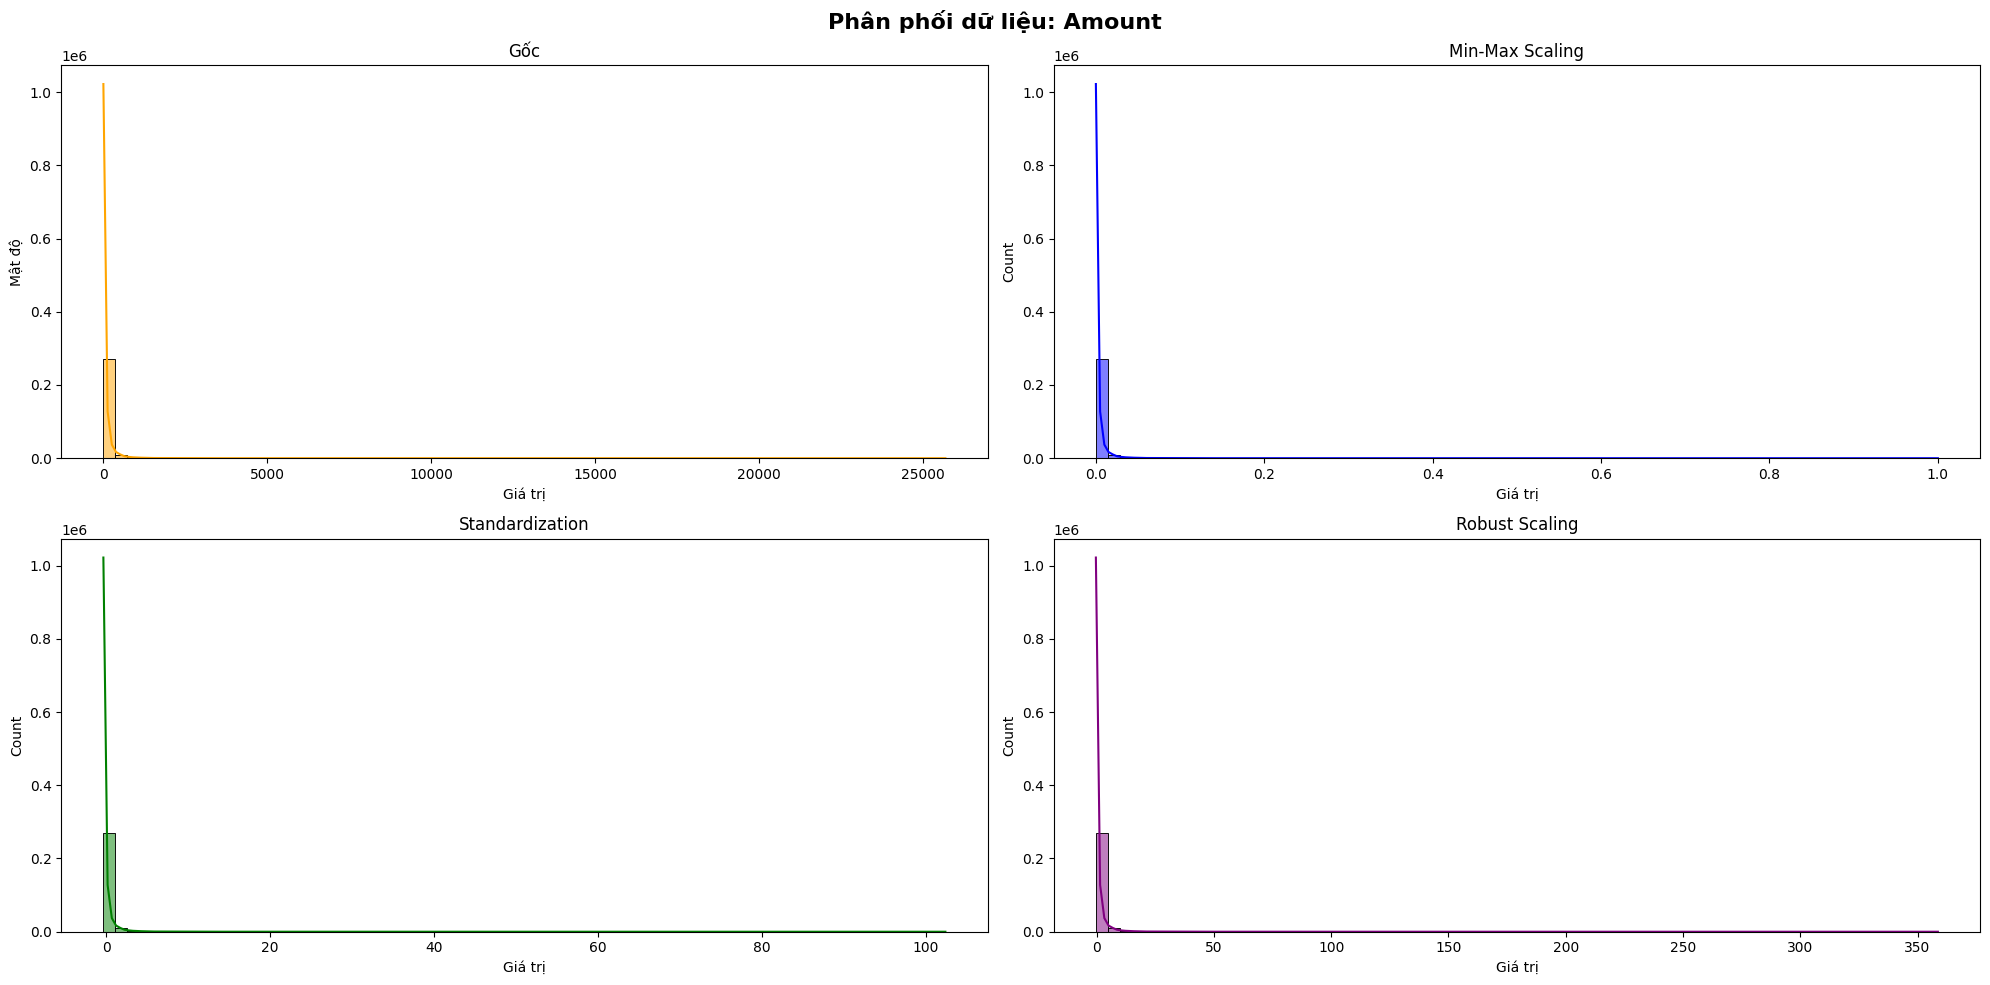

In [35]:
for col in numerical_cols:
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    fig.suptitle(f'Phân phối dữ liệu: {col}', fontsize=16, fontweight='bold')

    # Original
    sns.histplot(
        data[col],
        bins=70,
        kde=True,
        ax=axes[0, 0],
        color='orange'
    )
    axes[0, 0].set_title('Gốc')
    axes[0, 0].set_xlabel('Giá trị')
    axes[0, 0].set_ylabel('Mật độ')

    # Min-Max Scaling
    sns.histplot(
        data_minmax[col],
        bins=70,
        kde=True,
        ax=axes[0, 1],
        color='blue'
    )
    axes[0, 1].set_title('Min-Max Scaling')
    axes[0, 1].set_xlabel('Giá trị')

    # Standardization
    sns.histplot(
        data_standard[col],
        bins=70,
        kde=True,
        ax=axes[1, 0],
        color='green'
    )
    axes[1, 0].set_title('Standardization')
    axes[1, 0].set_xlabel('Giá trị')

    # Robust Scaling
    sns.histplot(
        data_robust[col],
        bins=70,
        kde=True,
        ax=axes[1, 1],
        color='purple'
    )
    axes[1, 1].set_title('Robust Scaling')
    axes[1, 1].set_xlabel('Giá trị')

    plt.tight_layout()
    plt.show()


- Phân tích để quyết định phương pháp được sử dụng: Trong tập dữ liệu Credit Card Fraud Detection, các biến số học (đặc biệt là `Time` và `Amount`) có đặc điểm phân phối rất khác nhau. Do đó, việc lựa chọn phương pháp chuẩn hóa cần dựa trên **hình dạng phân phối**, **mức độ lệch (skewness)** và **ảnh hưởng của các giá trị ngoại lai (outliers)**. Ta sẽ xem ba phương pháp được sử dụng để chuẩn hóa chúng

---

### Min-Max Scaling:
- Với biến **Time**:  
  Phân phối sau Min-Max Scaling giữ nguyên hình dạng ban đầu (đa đỉnh, không chuẩn). Không xuất hiện biến dạng nghiêm trọng.
- Với biến **Amount**:  
  Do tồn tại một số giá trị rất lớn (outliers), toàn bộ phần lớn dữ liệu bị **nén sát về 0**. Điều này làm mất khả năng phân biệt giữa các giao dịch có giá trị nhỏ và trung bình.

**Đánh giá**
> Min-Max Scaling **không phù hợp** cho tập dữ liệu này do biến `Amount` có outlier cực lớn làm méo toàn bộ không gian đặc trưng.

---

### Standardization (Z-score Normalization)

- Với biến **Time**:  
  Phân phối không chuẩn (multi-modal), do đó mean và standard deviation **không đại diện tốt cho dữ liệu**. Việc chuẩn hóa không cải thiện cấu trúc phân phối.
- Với biến **Amount**:  
  Mean và standard deviation bị **kéo lệch mạnh bởi outlier**, khiến phần lớn dữ liệu tập trung sát quanh 0, trong khi các outlier vẫn có giá trị rất lớn.

**Đánh giá**
> Mặc dù tỷ lệ outlier không quá cao, **mức độ ảnh hưởng của outlier rất lớn**, khiến Standardization không phải là lựa chọn tối ưu cho tập dữ liệu này.

---

### Robust Scaling:

- Với biến **Time**:  
  Phân phối sau chuẩn hóa giữ được hình dạng ban đầu, không bị ảnh hưởng tiêu cực.
- Với biến **Amount**:  
  Phần lớn dữ liệu được trải đều hơn, trong khi các outlier vẫn tồn tại nhưng **không chi phối toàn bộ phân phối**.

**Đánh giá**
> Robust Scaling thể hiện sự cân bằng tốt nhất giữa việc giảm ảnh hưởng của outlier và giữ lại thông tin quan trọng của dữ liệu.

---

### Kết luận lựa chọn phương pháp chuẩn hóa

Dựa trên phân tích trực quan phân phối và bản chất dữ liệu, **Robust Scaling là phương pháp chuẩn hóa phù hợp nhất cho tập dữ liệu này**, đặc biệt trong bối cảnh dữ liệu tài chính có phân phối lệch và tồn tại các giá trị ngoại lai lớn.


In [36]:
data_normalized = data_robust.copy()
scaler_used = "Robust Scaling"

### V. Chuẩn hóa các cột định danh: 

- Lấy ra các giá trị định danh

In [37]:
# Lấy ra các cột định danh từ tập dữ liệu đã chuẩn hóa
categorical_cols = data_normalized.select_dtypes(include=['object']).columns.tolist()

print(f"\nCác cột định danh: {len(categorical_cols)}")
print(f"Các cột: {categorical_cols}")


Các cột định danh: 0
Các cột: []


&rarr; Vì không có cột định danh nên ta sẽ không thực hiện việc chuẩn hóa

### VI. Lựa chọn đặc trưng: 

In [38]:
# Lấy ra tất cả các cột đặc trưng (số và định danh) từ tập dữ liệu đã chuẩn hóa
all_features = data_normalized.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

print(f"\nTổng số đặc trưng: {len(all_features)}")
print(f"Kích thước bộ dữ liệu: {data_normalized.shape}")


Tổng số đặc trưng: 31
Kích thước bộ dữ liệu: (284807, 31)


&rarr; Thử những phương pháp khác nhau để chọn lọc những đặc trưng quan trọng.


Phương pháp 1: Tương quan với biến mục tiêu (Class)


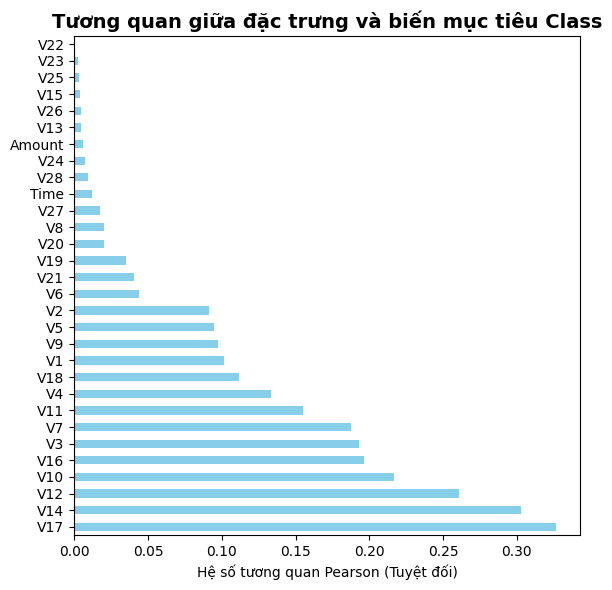

In [39]:
# Method 1: Ma trận tương quan với biến mục tiêu (Class)
print("\n" + "="*60)
print("Phương pháp 1: Tương quan với biến mục tiêu (Class)")
print("="*60)

# Tính hệ số tương quan Pearson giữa tất cả đặc trưng và biến mục tiêu 'Class'
corr_with_target = data_normalized[all_features].corr()['Class'].abs().sort_values(ascending=False)
corr_with_target.drop('Class', inplace=True)

# Trực quan hệ số tương quan của tất cả đặc trưng với biến mục tiêu
plt.figure(figsize=(6, 6))
corr_with_target.plot(
    kind='barh',
    color = 'skyblue'
)
plt.axvline(0, linestyle='--')
plt.title('Tương quan giữa đặc trưng và biến mục tiêu Class', fontsize=14, fontweight='bold')
plt.xlabel('Hệ số tương quan Pearson (Tuyệt đối)')
plt.tight_layout()
plt.show()


In [40]:
# Ngưỡng tương quan
corr_threshold = 0.2

# Lấy các đặc trưng có hệ số tương quan tuyệt đối >= ngưỡng
features_after_corr = corr_with_target[corr_with_target >= corr_threshold].index.tolist()

# Print results
print(f"\n✓ Ngưỡng tương quan |corr| ≥ {corr_threshold}")
print(f"✓ Số đặc trưng được giữ lại: {len(features_after_corr)} / {len(all_features)}")
print("\nDanh sách đặc trưng được chọn:")
for f in features_after_corr:
    print(f"  {f}: corr = {corr_with_target[f]:.3f}")


✓ Ngưỡng tương quan |corr| ≥ 0.2
✓ Số đặc trưng được giữ lại: 4 / 31

Danh sách đặc trưng được chọn:
  V17: corr = 0.326
  V14: corr = 0.303
  V12: corr = 0.261
  V10: corr = 0.217


In [41]:
# Method 2: Ngưỡng phương sai
print("\n" + "="*60)
print("Phương pháp 2: Ngưỡng phương sai")
print("="*60)

variance_threshold = 0.01  # Loại bỏ các đặc trưng có phương sai < 0.01

# Tách feature và target cho chắc chắn
features_without_target = [f for f in all_features if f != 'Class']

# Khởi tạo VarianceThreshold
var_selector = VarianceThreshold(threshold=variance_threshold)

# Fit trên feature ONLY (không có Class)
var_selector.fit(data_normalized[features_without_target])

# Mask các feature được giữ lại
var_mask = var_selector.get_support()

# Danh sách feature sau khi lọc
features_after_variance = [
    f for f, selected in zip(features_without_target, var_mask) if selected
]

# In kết quả
print(f"\nNgưỡng phương sai: {variance_threshold}")
print(f"✓ Đặc trưng có phương sai đủ lớn: {len(features_after_variance)}")
print(features_after_variance)

print(
    f"✓ Đặc trưng có phương sai thấp bị loại bỏ: "
    f"{len(features_without_target) - len(features_after_variance)}"
)



Phương pháp 2: Ngưỡng phương sai

Ngưỡng phương sai: 0.01
✓ Đặc trưng có phương sai đủ lớn: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
✓ Đặc trưng có phương sai thấp bị loại bỏ: 0



Phương pháp 3: Độ quan trọng của đặc trưng (Random Forest)

Độ quan trọng của các đặc trưng:
V14       0.175555
V10       0.112880
V4        0.112270
V12       0.101297
V17       0.088148
V3        0.061046
V11       0.057901
V16       0.055982
V2        0.029452
V7        0.021061
V21       0.018469
V9        0.018443
V19       0.013146
Amount    0.012287
V27       0.011180
V18       0.010222
V8        0.010044
V20       0.009811
V1        0.008876
V26       0.008310
V5        0.008273
V13       0.008142
V6        0.006631
V23       0.006604
V28       0.006381
V15       0.006378
V22       0.006226
V25       0.005917
Time      0.004772
V24       0.004297
dtype: float64


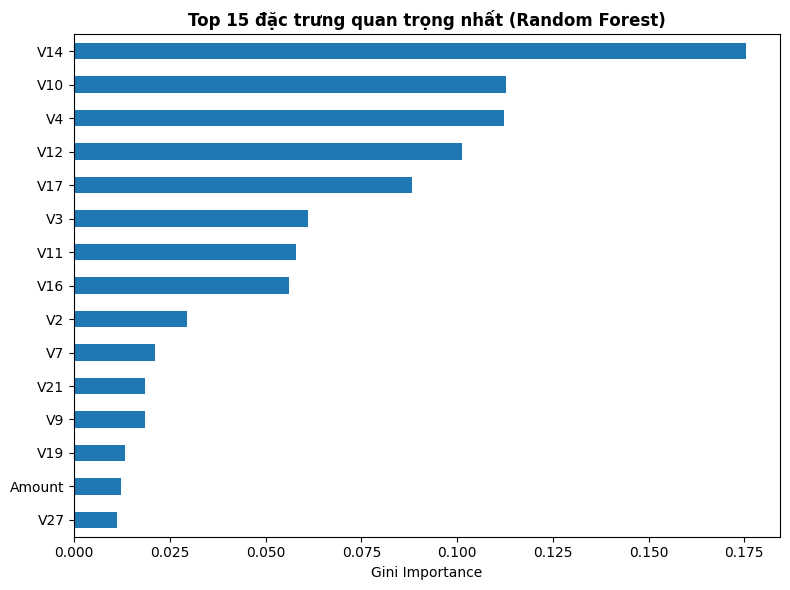


✓ Top 15 đặc trưng được chọn:
['V14', 'V10', 'V4', 'V12', 'V17', 'V3', 'V11', 'V16', 'V2', 'V7', 'V21', 'V9', 'V19', 'Amount', 'V27']


In [42]:
# Method 3: Độ quan trọng của đặc trưng (Random Forest)
print("\n" + "="*60)
print("Phương pháp 3: Độ quan trọng của đặc trưng (Random Forest)")
print("="*60)

# Xác định biến mục tiêu
target_col = 'Class'

# Tách feature và target
feature_cols = [f for f in all_features if f != target_col]

X = data_normalized[feature_cols]
y = data_normalized[target_col]

# Huấn luyện Random Forest Classifier (xử lý imbalance)
model_RandomForest = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_RandomForest.fit(X, y)

# Feature importance
feature_importances = pd.Series(
    model_RandomForest.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nĐộ quan trọng của các đặc trưng:")
print(feature_importances)

# Visualization: Top 15 features
top_k = 15
plt.figure(figsize=(8, 6))
feature_importances.head(top_k).plot(
    kind='barh'
)
plt.gca().invert_yaxis()
plt.xlabel('Gini Importance')
plt.title(f'Top {top_k} đặc trưng quan trọng nhất (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

# Selected features
features_after_importance = feature_importances.head(top_k).index.tolist()
print(f"\n✓ Top {top_k} đặc trưng được chọn:")
print(features_after_importance)

In [43]:
# Method 4: Loại bỏ đặc trưng đệ quy (RFE)
print("\n" + "="*60)
print("Phương pháp 4: Loại bỏ đặc trưng đệ quy (RFE)")
print("="*60)

# Xác định biến mục tiêu
target_col = 'Class'

# Tách feature và target
feature_cols = [f for f in all_features if f != target_col]

X_RFE = data_normalized[feature_cols]
y_RFE = data_normalized[target_col]

# Số đặc trưng cần chọn
n_features_to_select = min(15, len(feature_cols))
print(f"\nLựa chọn {n_features_to_select} đặc trưng bằng RFE...")

# Logistic Regression (phù hợp cho phân loại nhị phân)
estimator = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# RFE
rfe = RFE(
    estimator=estimator,
    n_features_to_select=n_features_to_select,
    step=1
)

# Fit RFE
rfe.fit(X_RFE, y_RFE)

# Feature được chọn
features_after_rfe = X_RFE.columns[rfe.support_].tolist()
print(f"\n✓ Đặc trưng được chọn bởi RFE ({len(features_after_rfe)}):")
print(features_after_rfe)

# Bảng xếp hạng feature
rfe_ranking = pd.DataFrame({
    'Đặc trưng': X_RFE.columns,
    'Hạng': rfe.ranking_,
    'Được chọn': rfe.support_
}).sort_values('Hạng')

print("\nTop đặc trưng theo thứ hạng RFE:")
print(rfe_ranking)



Phương pháp 4: Loại bỏ đặc trưng đệ quy (RFE)

Lựa chọn 15 đặc trưng bằng RFE...

✓ Đặc trưng được chọn bởi RFE (15):
['Time', 'V4', 'V5', 'V6', 'V8', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V22', 'V26', 'V28']

Top đặc trưng theo thứ hạng RFE:
   Đặc trưng  Hạng  Được chọn
0       Time     1       True
6         V6     1       True
5         V5     1       True
4         V4     1       True
12       V12     1       True
11       V11     1       True
10       V10     1       True
8         V8     1       True
14       V14     1       True
13       V13     1       True
17       V17     1       True
28       V28     1       True
26       V26     1       True
22       V22     1       True
16       V16     1       True
9         V9     2      False
1         V1     3      False
20       V20     4      False
29    Amount     5      False
2         V2     6      False
19       V19     7      False
7         V7     8      False
23       V23     9      False
3         V3    10      


                 Phương pháp  Số đặc trưng được chọn  Tỷ lệ giảm (%)
               Đặc trưng gốc                      31        0.000000
Tương quan với biến mục tiêu                       4       87.096774
                  Phương sai                      30        3.225806
    Random Forest Importance                      15       51.612903
                         RFE                      15       51.612903


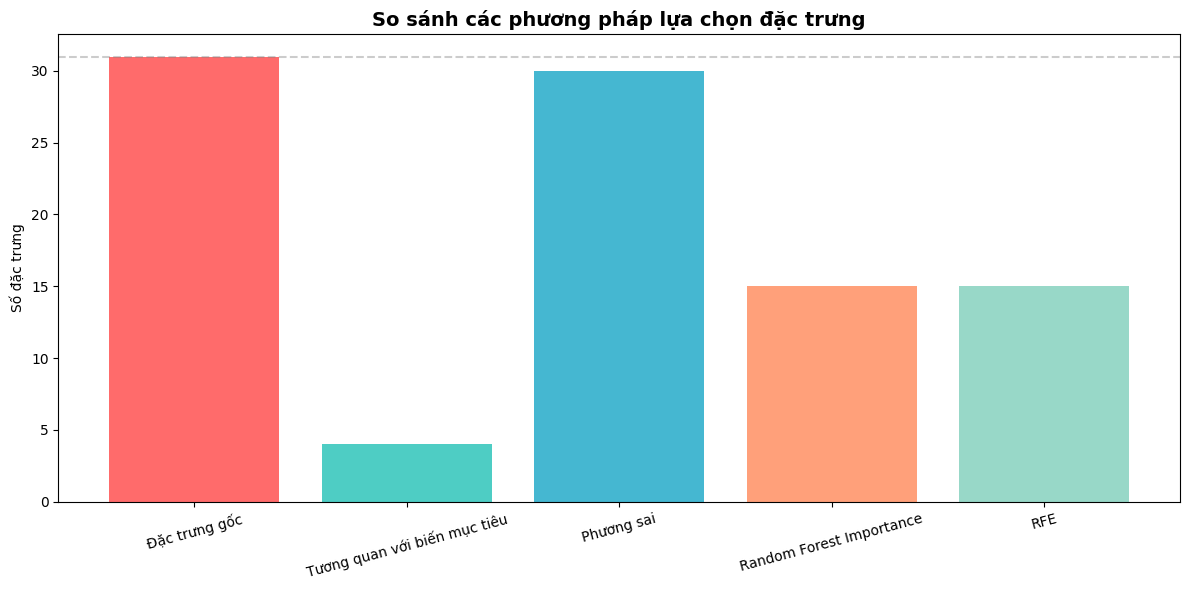


Tổng hợp đặc trưng được chọn bởi các phương pháp
Phương pháp 1 - Tương quan với biến mục tiêu {'V10', 'V14', 'V17', 'V12'}
Phương pháp 2 - Phương sai {'V20', 'V27', 'Time', 'V6', 'V16', 'V25', 'V19', 'V14', 'Amount', 'V1', 'V21', 'V8', 'V15', 'V13', 'V18', 'V2', 'V28', 'V3', 'V24', 'V17', 'V23', 'V26', 'V11', 'V12', 'V4', 'V10', 'V5', 'V22', 'V9', 'V7'}
Phương pháp 3 - Random Forest {'V21', 'V27', 'V16', 'V12', 'V11', 'V2', 'V19', 'V14', 'V4', 'V9', 'Amount', 'V3', 'V10', 'V7', 'V17'}
Phương pháp 4 - RFE {'V8', 'V5', 'V13', 'V22', 'Time', 'V6', 'V26', 'V16', 'V11', 'V12', 'V4', 'V14', 'V28', 'V10', 'V17'}

Phân tích giao nhau giữa các phương pháp
Đặc trưng chung của TẤT CẢ phương pháp: 4
Đặc trưng được ≥ 3 phương pháp chọn: 7
1. V10
2. V11
3. V12
4. V14
5. V16
6. V17
7. V4


In [44]:
comparison = pd.DataFrame({
    'Phương pháp': [
        'Đặc trưng gốc',
        'Tương quan với biến mục tiêu',
        'Phương sai',
        'Random Forest Importance',
        'RFE'
    ],
    'Số đặc trưng được chọn': [
        len(all_features),
        len(features_after_corr),
        len(features_after_variance),
        len(features_after_importance),
        len(features_after_rfe)
    ]
})

comparison['Tỷ lệ giảm (%)'] = (
    1 - comparison['Số đặc trưng được chọn'] / len(all_features)
) * 100

print("\n" + comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.bar(
    comparison['Phương pháp'],
    comparison['Số đặc trưng được chọn'],
    color=colors
)
plt.axhline(len(all_features), linestyle='--', alpha=0.4, color='gray')
plt.title('So sánh các phương pháp lựa chọn đặc trưng', fontsize=14, fontweight='bold')
plt.ylabel('Số đặc trưng')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

set_corr = set(features_after_corr)
set_var = set(features_after_variance)
set_rf = set(features_after_importance)
set_rfe = set(features_after_rfe)

# In ra kết quả chọn đặc trưng của tưng phương pháp
print("\n" + "="*60)
print("Tổng hợp đặc trưng được chọn bởi các phương pháp")
print("="*60)
print(f"Phương pháp 1 - Tương quan với biến mục tiêu", set_corr)
print(f"Phương pháp 2 - Phương sai", set_var)
print(f"Phương pháp 3 - Random Forest", set_rf)
print(f"Phương pháp 4 - RFE", set_rfe)

common_all = set_corr & set_var & set_rf & set_rfe
common_three = (
    (set_corr & set_rf & set_rfe) |
    (set_corr & set_var & set_rf) |
    (set_corr & set_var & set_rfe) |
    (set_var & set_rf & set_rfe)
)

print("\n" + "="*60)
print("Phân tích giao nhau giữa các phương pháp")
print("="*60)
print(f"Đặc trưng chung của TẤT CẢ phương pháp: {len(common_all)}")
print(f"Đặc trưng được ≥ 3 phương pháp chọn: {len(common_three)}")
for i, f in enumerate(sorted(common_three), 1):
    print(f"{i}. {f}")



## Phân tích và lựa chọn phương pháp chọn đặc trưng
Ta sẽ phân tích từng phương pháp để chọn ra phương pháp tốt nhất

---

### Phương pháp 1: Lựa chọn đặc trưng dựa trên hệ số tương quan

Phương pháp này đánh giá mối quan hệ tuyến tính giữa từng đặc trưng và biến mục tiêu `Class` thông qua hệ số tương quan Pearson. Một ngưỡng tương quan được đặt ra để loại bỏ các đặc trưng có mức độ liên hệ thấp với biến mục tiêu.

**Kết quả thực nghiệm:**  
Với ngưỡng |correlation| ≥ 0.2, chỉ có 4 đặc trưng được giữ lại, bao gồm: `V10`, `V12`, `V14`, `V17`.

**Đánh giá:**  
Phương pháp này đơn giản, dễ diễn giải và giúp nhanh chóng xác định các trục PCA có mối liên hệ tuyến tính mạnh nhất với gian lận. Tuy nhiên, do dữ liệu đã được PCA, nhiều trục có thể đóng vai trò quan trọng thông qua tương tác phi tuyến hoặc kết hợp nhiều chiều, nhưng lại có hệ số tương quan tuyến tính thấp. Việc chỉ giữ lại 4/31 đặc trưng dẫn đến nguy cơ mất mát thông tin đáng kể.

**Kết luận:**  
> Phương pháp tương quan phù hợp để tham khảo ban đầu, nhưng không đủ mạnh để sử dụng làm phương pháp lựa chọn đặc trưng chính trong bài toán này.

---

### Phương pháp 2: Ngưỡng phương sai (Variance Threshold)

Phương pháp ngưỡng phương sai loại bỏ các đặc trưng có phương sai nhỏ hơn một ngưỡng xác định, với giả định rằng các biến có phương sai thấp ít mang thông tin.

**Kết quả thực nghiệm:**  
Với ngưỡng phương sai 0.01, không có đặc trưng nào bị loại bỏ; toàn bộ 30 đặc trưng đầu vào đều được giữ lại.

**Đánh giá:**  
Kết quả này hoàn toàn phù hợp với đặc điểm của dữ liệu, do các đặc trưng V1–V28 đã được PCA và chuẩn hóa về phương sai. Trong bối cảnh này, phương pháp ngưỡng phương sai không có khả năng phân biệt mức độ quan trọng giữa các đặc trưng.
 
>Variance Threshold không phù hợp để lựa chọn đặc trưng cho tập dữ liệu này và chỉ có thể xem là một bước tiền xử lý tối thiểu nhằm loại bỏ các biến hằng (nếu tồn tại).

---

### Phương pháp 3: Random Forest Feature Importance

Phương pháp này sử dụng mô hình Random Forest để đánh giá tầm quan trọng của từng đặc trưng dựa trên mức độ đóng góp vào việc giảm độ hỗn loạn (Gini impurity) trong quá trình huấn luyện.

**Kết quả thực nghiệm:**  
Random Forest xác định khoảng 15 đặc trưng quan trọng nhất, trong đó các đặc trưng nổi bật bao gồm:  
`V14`, `V10`, `V4`, `V12`, `V17`, `V3`, `V11`, `V16`, ...

**Đánh giá:**  
Random Forest là mô hình phi tuyến, có khả năng khai thác tương tác phức tạp giữa các đặc trưng và không bị ảnh hưởng bởi giả định tuyến tính của PCA. Phương pháp này hoạt động tốt trong bối cảnh dữ liệu mất cân bằng và phản ánh trực tiếp đóng góp của đặc trưng vào hiệu năng dự đoán của mô hình.

Mặc dù độ quan trọng dựa trên Gini có thể bị thiên lệch trong một số trường hợp, nhưng trong thực nghiệm, phương pháp này cho ra tập đặc trưng hợp lý và ổn định.
  
>Random Forest Feature Importance là phương pháp đơn lẻ mạnh nhất và phù hợp nhất cho bài toán lựa chọn đặc trưng trong tập dữ liệu này.

---

### Phương pháp 4: Recursive Feature Elimination (RFE)

RFE là phương pháp lựa chọn đặc trưng dựa trên mô hình, trong đó các đặc trưng kém quan trọng nhất sẽ được loại bỏ dần dựa trên trọng số của mô hình học máy. Trong thí nghiệm này, Logistic Regression được sử dụng làm bộ ước lượng.

**Kết quả thực nghiệm:**  
RFE lựa chọn khoảng 15 đặc trưng, với tập đặc trưng có sự chồng lấn đáng kể với Random Forest, bao gồm nhiều đặc trưng như `V10`, `V12`, `V14`, `V16`, `V17` và một số đặc trưng khác.

**Đánh giá:**  
RFE kết hợp tốt giữa khả năng dự đoán và tính diễn giải, đồng thời phản ánh trực tiếp tác động của đặc trưng lên mô hình phân loại. Tuy nhiên, do Logistic Regression giả định mối quan hệ tuyến tính, phương pháp này có thể bỏ sót các tương tác phi tuyến phức tạp.

>RFE là một phương pháp hiệu quả và phù hợp để kiểm chứng và bổ sung cho các phương pháp dựa trên mô hình phi tuyến.

---

### Kết luận cuối cùng

Trong bối cảnh tập dữ liệu Credit Card Fraud Detection, không tồn tại một phương pháp lựa chọn đặc trưng duy nhất là tối ưu tuyệt đối. Tuy nhiên, dựa trên kết quả thực nghiệm và phân tích lý thuyết:

- **Random Forest Feature Importance** là phương pháp hiệu quả và phù hợp nhất để lựa chọn đặc trưng chính.
- **RFE** đóng vai trò quan trọng trong việc kiểm chứng và củng cố kết quả.
- **Correlation Filter** chỉ nên sử dụng để tham khảo.
- **Variance Threshold** không có giá trị lựa chọn đặc trưng trong tập dữ liệu này.

Nếu chỉ được chọn một phương pháp tối ưu nhất thì chúng em sẽ chọn phương pháp **Random Forest Feature Important** còn nếu được sử dụng kết hợp các phương pháp thì chiến lược chúng em muốn đề xuất là sử dụng tập giao của các phương pháp dựa trên mô hình, đặc biệt là Random Forest và RFE, nhằm thu được tập đặc trưng ổn định, giàu thông tin và giảm nguy cơ overfitting.

Mặc dù việc kết hợp giữa nhiều phương pháp có thể sẽ làm mất đi nhiều đặc trưng hơn so với một phương pháp cố định, nhưng ta có thể lấy ra được tập đặc trưng tốt nhất được lựa chọn nhất quán bởi nhiều phương pháp khác nhau. Cụ thể, trong trường hợp này ta vẫn chọn ra được 7 đặc trưng đồng nhất xuất hiện trong kết quả của ít nhất ba phương pháp:

`V4`, `V10`, `V11`, `V12`, `V14`, `V16`, `V17`.

> Các đặc trưng này thể hiện tính ổn định cao và ít phụ thuộc vào giả định riêng lẻ của từng phương pháp.

